In [1]:
# ── CELL 0: Session setup ──────────────────────────────────────
# Run this first every new session, then Run All remaining cells

import torch, pandas as pd, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, copy, os
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__} | Device: {device}")
print("Session ready. Now run all remaining cells.")

PyTorch: 2.10.0+cu128 | Device: cuda
Session ready. Now run all remaining cells.


In [2]:
# Finding where Kaggle put the dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikitamittal123/etth1-csv/ETTh1.csv


In [18]:
import json
import pickle

# ── Result Storage Setup ─────────────────────────────────────────
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

def remove_non_serializable(data):
    if isinstance(data, dict):
        return {
            k: remove_non_serializable(v)
            for k, v in data.items()
            if k != 'model'   # ❗ remove model
        }
    elif isinstance(data, list):
        return [remove_non_serializable(i) for i in data]
    return data

def save_results(data, filename):
    """
    Saves any Python dictionary to both pickle and JSON.
    pickle → for loading back into Python perfectly
    JSON   → for reading as plain text anytime
    """
    pkl_path  = f"{RESULTS_DIR}/{filename}.pkl"
    json_path = f"{RESULTS_DIR}/{filename}.json"

    # Save as pickle (preserves all Python objects)
    with open(pkl_path, 'wb') as f:
        pickle.dump(data, f)

    # Save as JSON (human readable, can open in any text editor)
    # Convert numpy floats to regular floats for JSON compatibility
    def convert(obj):
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, dict):
            return {str(k): convert(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [convert(i) for i in obj]
        return obj

    with open(json_path, 'w') as f:
        json.dump(convert(data), f, indent=2)

    print(f"  Saved: {filename}.pkl  and  {filename}.json")

def load_results(filename):
    """Loads previously saved results back into Python."""
    pkl_path = f"{RESULTS_DIR}/{filename}.pkl"
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        print(f"  Loaded: {filename}.pkl")
        return data
    else:
        print(f"  Not found: {filename}.pkl — need to run experiment")
        return None

def save_history_csv(history_dict, filename):
    """
    Saves per-round training history as a CSV file.
    history_dict format: {model_name: {alpha: {'history': {...}}}}
    This CSV can be opened in Excel for quick inspection.
    """
    rows = []
    for model_name, alpha_results in history_dict.items():
        for alpha, result in alpha_results.items():
            h = result['history']
            for i, rnd in enumerate(h['round']):
                row = {
                    'model'    : model_name,
                    'alpha'    : alpha,
                    'round'    : rnd,
                    'test_mae' : h['test_mae'][i],
                    'test_rmse': h['test_rmse'][i]
                }
                rows.append(row)
    df_hist = pd.DataFrame(rows)
    csv_path = f"{RESULTS_DIR}/{filename}.csv"
    df_hist.to_csv(csv_path, index=False)
    print(f"  Saved history CSV: {filename}.csv  ({len(rows)} rows)")
    return df_hist

def save_summary_csv(results_dict, algorithm_name):
    """
    Saves final MAE/RMSE summary as a clean CSV table.
    One row per model+alpha combination.
    """
    rows = []
    for model_name, alpha_results in results_dict.items():
        for alpha, result in alpha_results.items():
            rows.append({
                'algorithm': algorithm_name,
                'model'    : model_name,
                'alpha'    : alpha,
                'final_mae': result['mae'],
                'final_rmse': result['rmse']
            })
    df_sum = pd.DataFrame(rows)
    csv_path = f"{RESULTS_DIR}/{algorithm_name}_summary.csv"
    df_sum.to_csv(csv_path, index=False)
    print(f"  Saved summary CSV: {algorithm_name}_summary.csv")
    return df_sum

print("Result management functions ready.")
print(f"Save location: {RESULTS_DIR}")

Results will be saved to: /kaggle/working/results
Result management functions ready.
Save location: /kaggle/working/results


In [4]:
df = pd.read_csv('/kaggle/input/datasets/nikitamittal123/etth1-csv/ETTh1.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (17420, 8)

Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First 3 rows:
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001

Missing values:
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Data types:
date     object
HUFL    float64
HULL    float64
MUFL    float64
MULL    float64
LUFL    float64
LULL    float64
OT      float64
dtype: object


In [5]:
# Convert the date column from text to actual datetime format
# Then set it as the index so pandas knows this is time series data
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print("Date range:")
print("  Start:", df.index.min())
print("  End:  ", df.index.max())
print("\nTotal hours:", len(df))
print("\nData after setting date as index:")
print(df.head(3))

Date range:
  Start: 2016-07-01 00:00:00
  End:   2018-06-26 19:00:00

Total hours: 17420

Data after setting date as index:
                      HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
date                                                                    
2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001


In [6]:
# Split the data by time — NEVER shuffle time series data
# Standard split: 70% train, 10% validation, 20% test
# This must be done BEFORE normalization to prevent data leakage

n = len(df)
train_end = int(n * 0.7)   # row 12194
val_end   = int(n * 0.8)   # row 13936

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("Split sizes:")
print(f"  Train: {len(df_train)} rows  ({len(df_train)/n*100:.1f}%)")
print(f"  Val:   {len(df_val)} rows  ({len(df_val)/n*100:.1f}%)")
print(f"  Test:  {len(df_test)} rows  ({len(df_test)/n*100:.1f}%)")
print(f"  Total: {len(df_train)+len(df_val)+len(df_test)} rows")

print("\nTrain period:", df_train.index.min(), "→", df_train.index.max())
print("Val period:  ", df_val.index.min(),   "→", df_val.index.max())
print("Test period: ", df_test.index.min(),  "→", df_test.index.max())

Split sizes:
  Train: 12194 rows  (70.0%)
  Val:   1742 rows  (10.0%)
  Test:  3484 rows  (20.0%)
  Total: 17420 rows

Train period: 2016-07-01 00:00:00 → 2017-11-21 01:00:00
Val period:   2017-11-21 02:00:00 → 2018-02-01 15:00:00
Test period:  2018-02-01 16:00:00 → 2018-06-26 19:00:00


In [7]:
# StandardScaler subtracts mean and divides by std deviation
# This brings all 7 features to a similar scale
# CRITICAL: fit ONLY on train data, then apply to val and test
# Fitting on all data would be "data leakage" — the model would
# indirectly know future statistics during training

scaler = StandardScaler()

# fit_transform on train: learns mean+std AND transforms
train_scaled = scaler.fit_transform(df_train.values)

# transform only on val and test: uses train's mean+std
val_scaled   = scaler.transform(df_val.values)
test_scaled  = scaler.transform(df_test.values)

print("Scaling complete.")
print(f"\nTrain scaled shape: {train_scaled.shape}")
print(f"Val   scaled shape: {val_scaled.shape}")
print(f"Test  scaled shape: {test_scaled.shape}")

print("\nBefore scaling — Train stats (first feature HUFL):")
print(f"  Mean: {df_train['HUFL'].mean():.4f}")
print(f"  Std:  {df_train['HUFL'].std():.4f}")

print("\nAfter scaling — Train stats (first feature):")
print(f"  Mean: {train_scaled[:, 0].mean():.4f}  (should be ~0)")
print(f"  Std:  {train_scaled[:, 0].std():.4f}   (should be ~1)")

print("\nScaler means (one per feature):", scaler.mean_.round(4))

Scaling complete.

Train scaled shape: (12194, 7)
Val   scaled shape: (1742, 7)
Test  scaled shape: (3484, 7)

Before scaling — Train stats (first feature HUFL):
  Mean: 7.4449
  Std:  6.3512

After scaling — Train stats (first feature):
  Mean: 0.0000  (should be ~0)
  Std:  1.0000   (should be ~1)

Scaler means (one per feature): [ 7.4449  1.957   4.5495  0.6936  2.9161  0.7805 16.2947]


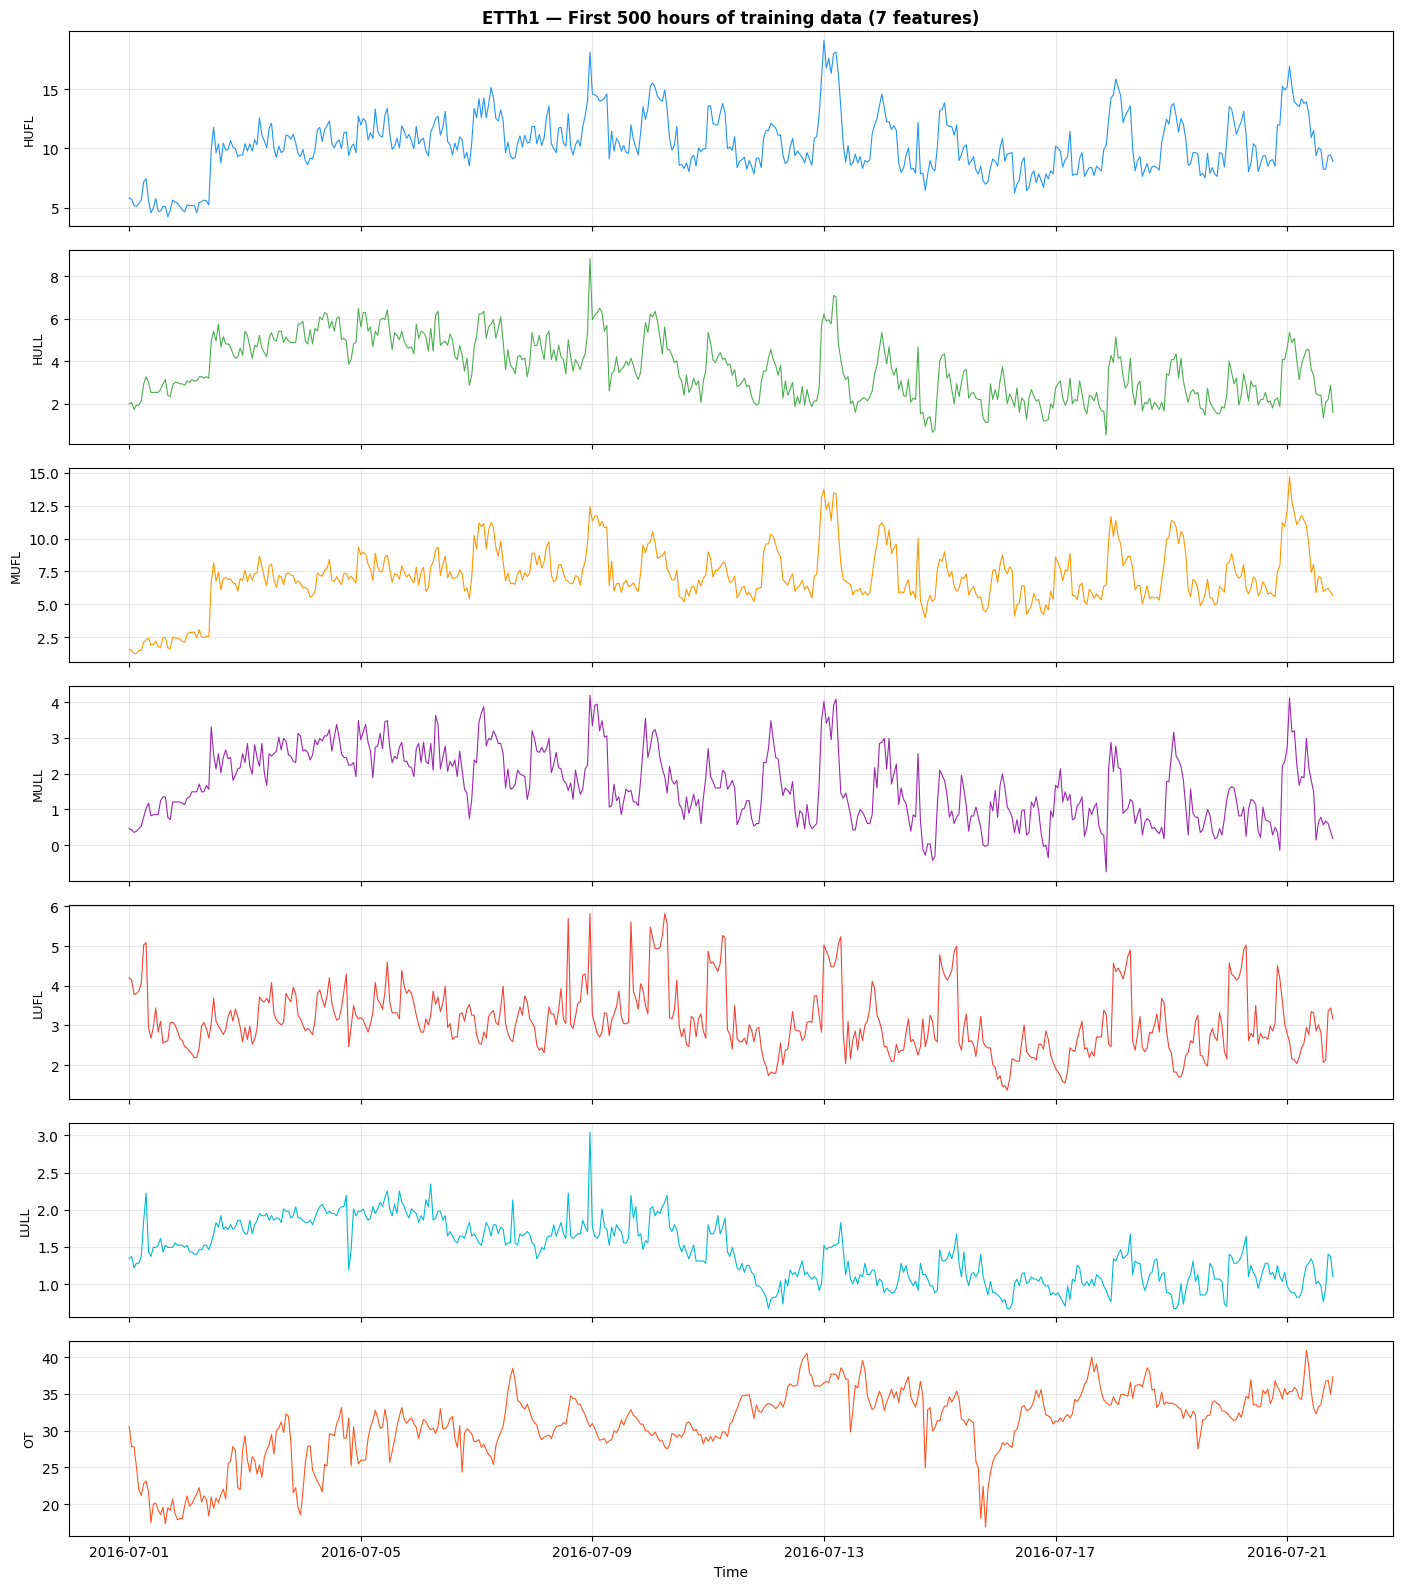

Plot saved.


In [8]:
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
feature_names = df_train.columns.tolist()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0',
          '#F44336', '#00BCD4', '#FF5722']

for i, (col, color) in enumerate(zip(feature_names, colors)):
    axes[i].plot(df_train.index[:500], df_train[col].values[:500],
                 color=color, linewidth=0.8, label='Train')
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('ETTh1 — First 500 hours of training data (7 features)',
                  fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('etth1_features.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [9]:
class TimeSeriesDataset(Dataset):
    """
    Converts a numpy array into (input_window, target_window) pairs.

    For each position i, we take:
      X = rows i to i+seq_len        (past 96 hours — the input)
      y = rows i+seq_len to i+seq_len+pred_len  (next 96 hours — to predict)

    This is called a sliding window because the window slides
    one step at a time across the full time series.
    """
    def __init__(self, data, seq_len=96, pred_len=96):
        self.data     = torch.FloatTensor(data)
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        # Total windows that fit in the data
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x_start = idx
        x_end   = idx + self.seq_len
        y_end   = x_end + self.pred_len

        x = self.data[x_start : x_end]   # shape: [96, 7]
        y = self.data[x_end   : y_end]   # shape: [96, 7]
        return x, y

# Create datasets from the scaled arrays
SEQ_LEN  = 96   # look back 96 hours (~4 days)
PRED_LEN = 96   # predict next 96 hours (~4 days)

train_dataset = TimeSeriesDataset(train_scaled, SEQ_LEN, PRED_LEN)
val_dataset   = TimeSeriesDataset(val_scaled,   SEQ_LEN, PRED_LEN)
test_dataset  = TimeSeriesDataset(test_scaled,  SEQ_LEN, PRED_LEN)

print("Dataset sizes (number of windows):")
print(f"  Train: {len(train_dataset)}")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")

# Verify one sample
x_sample, y_sample = train_dataset[0]
print(f"\nOne sample:")
print(f"  X shape: {x_sample.shape}  — input: 96 timesteps × 7 features")
print(f"  Y shape: {y_sample.shape}  — target: 96 timesteps × 7 features")
print(f"\nX first row (hour 0, all 7 features): {x_sample[0].numpy().round(4)}")
print(f"Y first row (hour 96, all 7 features): {y_sample[0].numpy().round(4)}")

Dataset sizes (number of windows):
  Train: 12003
  Val:   1551
  Test:  3293

One sample:
  X shape: torch.Size([96, 7])  — input: 96 timesteps × 7 features
  Y shape: torch.Size([96, 7])  — target: 96 timesteps × 7 features

X first row (hour 0, all 7 features): [-0.2547  0.0246 -0.4792 -0.1201  1.0828  0.8447  1.7053]
Y first row (hour 96, all 7 features): [0.7155 1.7364 0.6866 1.1701 0.2372 1.8108 1.1575]


**Dirichlet Non-IID Client Split**

In [10]:
def dirichlet_split(dataset, num_clients=10, alpha=1.0, seed=42):
    """
    Splits a dataset across clients using Dirichlet distribution.

    What Dirichlet does:
    - Generates 'num_clients' proportions that sum to 1
    - alpha controls how UNEQUAL those proportions are:
        alpha=10.0 → proportions are nearly equal (near-IID)
        alpha=1.0  → moderate differences (realistic)
        alpha=0.1  → very unequal (some clients get very little data)

    Example with 3 clients at alpha=0.1:
        Client 0: 78% of data
        Client 1: 19% of data
        Client 2:  3% of data   ← very heterogeneous
    """
    np.random.seed(seed)
    n_samples = len(dataset)
    indices = np.arange(n_samples)

    # Sample proportions from Dirichlet distribution
    proportions = np.random.dirichlet([alpha] * num_clients)

    # Convert proportions to actual sample counts
    sizes = (proportions * n_samples).astype(int)
    # Fix rounding so sizes sum exactly to n_samples
    sizes[-1] = n_samples - sizes[:-1].sum()

    # Shuffle indices so each client gets a random mix
    # (not just consecutive time blocks)
    np.random.shuffle(indices)

    # Assign indices to each client
    client_indices = []
    start = 0
    for size in sizes:
        client_indices.append(indices[start : start + size])
        start += size

    return client_indices


# --- Test all three alpha levels ---
NUM_CLIENTS = 10

print("=" * 55)
print("CLIENT DATA DISTRIBUTION ACROSS ALPHA LEVELS")
print("=" * 55)

for alpha in [10.0, 1.0, 0.1]:
    indices = dirichlet_split(train_dataset, NUM_CLIENTS, alpha)
    sizes   = [len(idx) for idx in indices]
    print(f"\nalpha = {alpha}  (total samples: {sum(sizes)})")
    print(f"  Per-client sizes: {sizes}")
    print(f"  Min: {min(sizes)}  Max: {max(sizes)}")
    print(f"  Std deviation:    {np.std(sizes):.1f}")
    print(f"  Imbalance ratio:  {max(sizes)/max(min(sizes),1):.1f}x")

CLIENT DATA DISTRIBUTION ACROSS ALPHA LEVELS

alpha = 10.0  (total samples: 12003)
  Per-client sizes: [1339, 1096, 1062, 1062, 1833, 1453, 982, 1358, 1238, 580]
  Min: 580  Max: 1833
  Std deviation:    314.8
  Imbalance ratio:  3.2x

alpha = 1.0  (total samples: 12003)
  Per-client sizes: [548, 3518, 1538, 1067, 198, 198, 69, 2350, 1074, 1443]
  Min: 69  Max: 3518
  Std deviation:    1030.3
  Imbalance ratio:  51.0x

alpha = 0.1  (total samples: 12003)
  Per-client sizes: [3, 2519, 0, 0, 351, 0, 9115, 0, 0, 15]
  Min: 0  Max: 9115
  Std deviation:    2741.3
  Imbalance ratio:  9115.0x


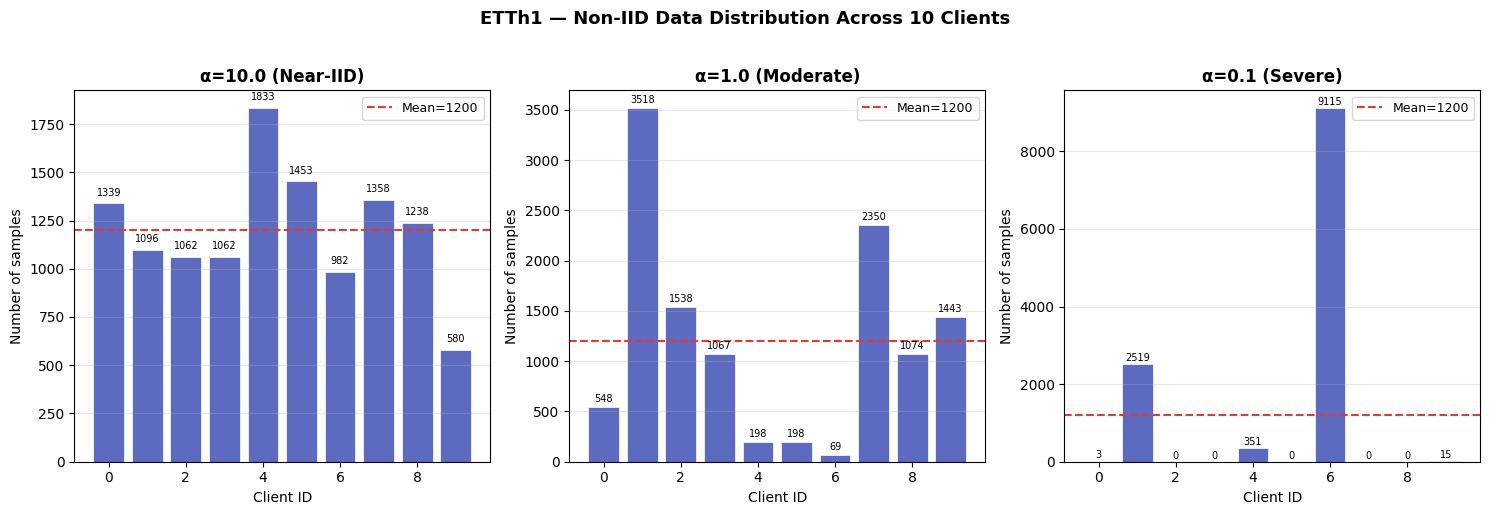

Distribution plot saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
alpha_levels = [10.0, 1.0, 0.1]
titles = ['α=10.0 (Near-IID)', 'α=1.0 (Moderate)', 'α=0.1 (Severe)']
colors = [f'#{hex(int(200-i*18))[2:]}6080' for i in range(NUM_CLIENTS)]

for ax, alpha, title in zip(axes, alpha_levels, titles):
    indices = dirichlet_split(train_dataset, NUM_CLIENTS, alpha)
    sizes   = [len(idx) for idx in indices]
    bars = ax.bar(range(NUM_CLIENTS), sizes,
                  color='#5C6BC0', edgecolor='white', linewidth=0.5)
    ax.axhline(y=np.mean(sizes), color='#E53935',
               linestyle='--', linewidth=1.5, label=f'Mean={np.mean(sizes):.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Client ID')
    ax.set_ylabel('Number of samples')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    # Annotate each bar with its value
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(size), ha='center', va='bottom', fontsize=7)

plt.suptitle('ETTh1 — Non-IID Data Distribution Across 10 Clients',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('noniid_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Distribution plot saved.")

In [12]:
import torch.nn as nn

# ─── Model 1: MLP ────────────────────────────────────────────────
class MLPModel(nn.Module):
    """
    Multi-Layer Perceptron — no temporal memory.
    Flattens the entire input window into one vector,
    passes through two linear layers, reshapes output.
    Serves as the BASELINE — shows performance without
    any sequence modeling.
    Parameters: ~200K
    """
    def __init__(self, seq_len=96, pred_len=96,
                 n_features=7, hidden=256):
        super().__init__()
        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.n_features = n_features
        self.net = nn.Sequential(
            nn.Linear(seq_len * n_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, pred_len * n_features)
        )

    def forward(self, x):              # x: [batch, 96, 7]
        b   = x.shape[0]
        out = self.net(x.reshape(b, -1))          # flatten → [batch, 672]
        return out.reshape(b, self.pred_len,
                           self.n_features)        # → [batch, 96, 7]


# ─── Model 2: LSTM ───────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    Long Short-Term Memory — strong temporal memory via cell state.
    Processes the sequence step by step, maintaining hidden state.
    Each timestep reads one row of 7 features.
    Parameters: ~200K
    """
    def __init__(self, n_features=7, hidden=64,
                 layers=2, pred_len=96, dropout=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden,
            num_layers  = layers,
            dropout     = dropout,
            batch_first = True       # input: [batch, seq, features]
        )
        self.fc = nn.Linear(hidden, n_features)

    def forward(self, x):            # x: [batch, 96, 7]
        out, _ = self.lstm(x)        # out: [batch, 96, 64]
        out = out[:, -self.pred_len:, :]  # last pred_len steps
        return self.fc(out)          # → [batch, 96, 7]


# ─── Model 3: GRU ────────────────────────────────────────────────
class GRUModel(nn.Module):
    """
    Gated Recurrent Unit — efficient temporal memory.
    Same idea as LSTM but with fewer parameters (no cell state).
    ~25% fewer parameters than LSTM → lower communication cost in FL.
    This is your PRIMARY model and hypothesis.
    Parameters: ~150K
    """
    def __init__(self, n_features=7, hidden=64,
                 layers=2, pred_len=96, dropout=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.gru = nn.GRU(
            input_size  = n_features,
            hidden_size = hidden,
            num_layers  = layers,
            dropout     = dropout,
            batch_first = True
        )
        self.fc = nn.Linear(hidden, n_features)

    def forward(self, x):            # x: [batch, 96, 7]
        out, _ = self.gru(x)         # out: [batch, 96, 64]
        out = out[:, -self.pred_len:, :]
        return self.fc(out)          # → [batch, 96, 7]


# ─── Verify all models ───────────────────────────────────────────
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
dummy_input = torch.randn(32, 96, 7).to(device)   # batch of 32 samples

models_to_test = {
    'MLP' : MLPModel().to(device),
    'LSTM': LSTMModel().to(device),
    'GRU' : GRUModel().to(device)
}

print("Model verification:")
print(f"{'Model':<8} {'Output shape':<25} {'Parameters':>12}")
print("-" * 47)
for name, model in models_to_test.items():
    output = model(dummy_input)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:<8} {str(output.shape):<25} {n_params:>12,}")

print(f"\nAll models running on: {device}")
print("Expected output shape for all: torch.Size([32, 96, 7])")

Model verification:
Model    Output shape                Parameters
-----------------------------------------------
MLP      torch.Size([32, 96, 7])        344,992
LSTM     torch.Size([32, 96, 7])         52,423
GRU      torch.Size([32, 96, 7])         39,431

All models running on: cuda
Expected output shape for all: torch.Size([32, 96, 7])


In [13]:
def evaluate_model(model, dataset, device, batch_size=64):
    """
    Runs the model on a dataset and returns MAE and RMSE.

    MAE  = Mean Absolute Error   → average prediction error in original units
    RMSE = Root Mean Square Error → penalises large errors more than MAE

    Both are calculated on SCALED values here.
    Lower is better for both metrics.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds  = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x    = x.to(device)
            pred = model(x)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # [N, 96, 7]
    targets = np.concatenate(all_targets, axis=0)   # [N, 96, 7]

    mae  = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))

    return round(float(mae), 6), round(float(rmse), 6)


# Quick sanity check with untrained GRU
test_model = GRUModel().to(device)
mae, rmse  = evaluate_model(test_model, test_dataset, device)
print(f"Untrained GRU — MAE: {mae}, RMSE: {rmse}")
print("(These should be large random values — model is not trained yet)")

Untrained GRU — MAE: 0.846983, RMSE: 1.108743
(These should be large random values — model is not trained yet)


In [14]:
def train_centralized(model_class, train_dataset, val_dataset,
                      test_dataset, model_name,
                      epochs=30, lr=0.001, batch_size=32,
                      n_features=7, device='cpu'):
    """
    Standard training — all data on one machine, no federation.
    This is the UPPER BOUND for your FL experiments.
    FL can never beat this (or if it does, something is wrong).
    """
    model     = model_class(n_features=n_features).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader    = DataLoader(train_dataset, batch_size=batch_size,
                           shuffle=True)

    history = {'epoch': [], 'train_loss': [],
               'val_mae': [], 'test_mae': []}

    print(f"\n{'='*50}")
    print(f"Centralized Training — {model_name}")
    print(f"{'='*50}")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Val MAE':<12} {'Test MAE'}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        # ── Training phase ──────────────────────────
        model.train()
        epoch_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)

        # ── Evaluation phase (every 5 epochs) ───────
        if epoch % 5 == 0:
            val_mae,  _  = evaluate_model(model, val_dataset,  device)
            test_mae, test_rmse = evaluate_model(model, test_dataset, device)
            history['epoch'].append(epoch)
            history['train_loss'].append(round(avg_loss, 6))
            history['val_mae'].append(val_mae)
            history['test_mae'].append(test_mae)
            print(f"{epoch:<8} {avg_loss:<14.6f} {val_mae:<12.6f} {test_mae:.6f}")

    # Final metrics
    final_mae, final_rmse = evaluate_model(model, test_dataset, device)
    print(f"\nFinal Test — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")
    return model, history, final_mae, final_rmse


# ── Run all 3 models centralized ────────────────────────────────
centralized_results = {}
model_classes = {'MLP': MLPModel, 'LSTM': LSTMModel, 'GRU': GRUModel}

for name, cls in model_classes.items():
    model, history, mae, rmse = train_centralized(
        model_class    = cls,
        train_dataset  = train_dataset,
        val_dataset    = val_dataset,
        test_dataset   = test_dataset,
        model_name     = name,
        epochs         = 30,
        lr             = 0.001,
        batch_size     = 32,
        n_features     = 7,
        device         = device
    )
    centralized_results[name] = {
        'model'  : model,
        'history': history,
        'mae'    : mae,
        'rmse'   : rmse
    }

# ── Summary table ────────────────────────────────────────────────
print("\n" + "="*45)
print("CENTRALIZED BASELINE SUMMARY")
print("="*45)
print(f"{'Model':<8} {'MAE':>10} {'RMSE':>10}")
print("-"*30)
for name, res in centralized_results.items():
    print(f"{name:<8} {res['mae']:>10.6f} {res['rmse']:>10.6f}")
print("\nThese are the upper bound targets.")
print("FL results should come close to these values.")


Centralized Training — MLP
Epoch    Train Loss     Val MAE      Test MAE
--------------------------------------------------
5        0.300428       0.555464     0.547455
10       0.275586       0.561409     0.555726
15       0.267368       0.545934     0.547724
20       0.254202       0.547919     0.567515
25       0.248243       0.536861     0.565524
30       0.242877       0.558095     0.582833

Final Test — MAE: 0.582833   RMSE: 0.783856

Centralized Training — LSTM
Epoch    Train Loss     Val MAE      Test MAE
--------------------------------------------------
5        0.214860       0.546393     0.664647
10       0.137903       0.601266     0.661289
15       0.110416       0.600968     0.655206
20       0.096478       0.600699     0.661305
25       0.087725       0.613102     0.658894
30       0.080547       0.623078     0.663526

Final Test — MAE: 0.663526   RMSE: 0.919504

Centralized Training — GRU
Epoch    Train Loss     Val MAE      Test MAE
---------------------------------

In [16]:
def train_centralized_v2(model_class, train_dataset, val_dataset,
                          test_dataset, model_name,
                          epochs=50, lr=0.0005, batch_size=32,
                          n_features=7, device='cpu',
                          patience=10):
    """
    Improved training with:
    1. Lower learning rate (0.0005 instead of 0.001)
       — prevents overshooting the optimal weights
    2. Early stopping (patience=10)
       — stops training when val MAE stops improving
       — prevents overfitting
    3. Best model checkpoint
       — saves the model at its best validation performance
    """
    model     = model_class(n_features=n_features).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=1e-4)  # L2 regularization
    criterion = nn.MSELoss()
    loader    = DataLoader(train_dataset, batch_size=batch_size,
                           shuffle=True)

    best_val_mae   = float('inf')
    best_weights   = None
    patience_count = 0
    history = {'epoch': [], 'train_loss': [], 'val_mae': [], 'test_mae': []}

    print(f"\n{'='*55}")
    print(f"Centralized Training v2 — {model_name}")
    print(f"{'='*55}")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Val MAE':<12} {'Test MAE':<12} {'Status'}")
    print("-" * 55)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)

        # Evaluate every epoch for early stopping
        val_mae,  _          = evaluate_model(model, val_dataset, device)
        test_mae, test_rmse  = evaluate_model(model, test_dataset, device)

        history['epoch'].append(epoch)
        history['train_loss'].append(round(avg_loss, 6))
        history['val_mae'].append(val_mae)
        history['test_mae'].append(test_mae)

        # Check if this is the best model so far
        status = ""
        if val_mae < best_val_mae:
            best_val_mae  = val_mae
            best_weights  = {k: v.clone()
                             for k, v in model.state_dict().items()}
            patience_count = 0
            status = "BEST"
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"{epoch:<8} {avg_loss:<14.6f} {val_mae:<12.6f}"
                      f" {test_mae:<12.6f} EARLY STOP")
                break

        if epoch % 5 == 0 or status == "BEST":
            print(f"{epoch:<8} {avg_loss:<14.6f} {val_mae:<12.6f}"
                  f" {test_mae:<12.6f} {status}")

    # Load best weights
    model.load_state_dict(best_weights)
    final_mae, final_rmse = evaluate_model(model, test_dataset, device)
    print(f"\nBest val MAE: {best_val_mae:.6f}")
    print(f"Final Test  — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")
    return model, history, final_mae, final_rmse


# ── Run improved training for all 3 models ──────────────────────
centralized_results_v2 = {}

for name, cls in model_classes.items():
    model, history, mae, rmse = train_centralized_v2(
        model_class   = cls,
        train_dataset = train_dataset,
        val_dataset   = val_dataset,
        test_dataset  = test_dataset,
        model_name    = name,
        epochs        = 50,
        lr            = 0.0005,
        n_features    = 7,
        device        = device,
        patience      = 10
    )
    centralized_results_v2[name] = {
        'model'  : model,
        'history': history,
        'mae'    : mae,
        'rmse'   : rmse
    }

# ── Comparison table ─────────────────────────────────────────────
print("\n" + "="*55)
print("CENTRALIZED BASELINE — v1 vs v2 COMPARISON")
print("="*55)
print(f"{'Model':<8} {'v1 MAE':>10} {'v2 MAE':>10} {'Improved?':>12}")
print("-"*42)
for name in model_classes:
    v1  = centralized_results[name]['mae']
    v2  = centralized_results_v2[name]['mae']
    imp = "YES" if v2 < v1 else "NO"
    print(f"{name:<8} {v1:>10.6f} {v2:>10.6f} {imp:>12}")

print("\nv2 results will be used as your final centralized baselines.")

# ── Save centralized results immediately after training ──────────
centralized_summary = []
for name in model_classes:
    centralized_summary.append({
        'model'     : name,
        'final_mae' : centralized_results_v2[name]['mae'],
        'final_rmse': centralized_results_v2[name]['rmse'],
        'history'   : centralized_results_v2[name]['history']
    })



Centralized Training v2 — MLP
Epoch    Train Loss     Val MAE      Test MAE     Status
-------------------------------------------------------
1        0.427803       0.514153     0.525097     BEST
2        0.343160       0.502883     0.514436     BEST
4        0.308133       0.489195     0.505585     BEST
5        0.299027       0.504954     0.519368     
10       0.276027       0.509306     0.522700     
14       0.267083       0.528855     0.530661     EARLY STOP

Best val MAE: 0.489195
Final Test  — MAE: 0.505585   RMSE: 0.706280

Centralized Training v2 — LSTM
Epoch    Train Loss     Val MAE      Test MAE     Status
-------------------------------------------------------
1        0.544820       0.552312     0.589555     BEST
2        0.393413       0.496306     0.578463     BEST
5        0.275267       0.560292     0.642265     
10       0.200493       0.596975     0.665973     
12       0.182789       0.582055     0.668174     EARLY STOP

Best val MAE: 0.496306
Final Test  — MAE

In [19]:
clean_results = remove_non_serializable(centralized_results_v2)

save_results(clean_results, 'centralized_results')
pd.DataFrame([{
    'model': r['model'],
    'mae'  : r['final_mae'],
    'rmse' : r['final_rmse']
} for r in centralized_summary]).to_csv(
    f"{RESULTS_DIR}/centralized_summary.csv", index=False
)
print("\nCentralized results saved.")

  Saved: centralized_results.pkl  and  centralized_results.json

Centralized results saved.


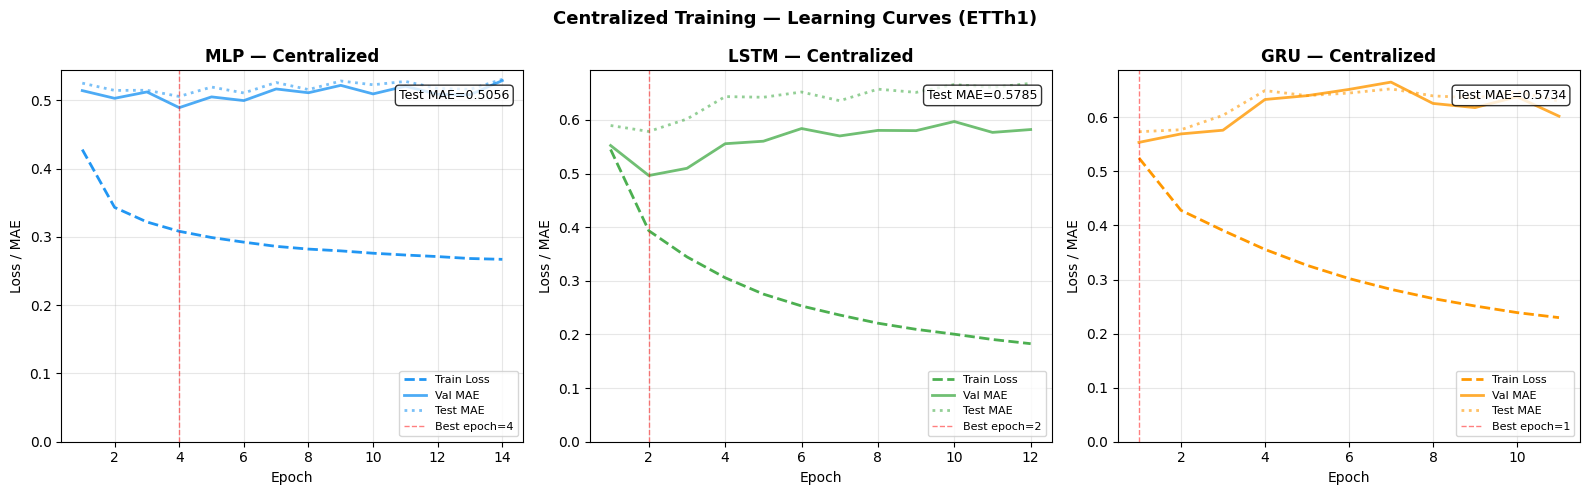

Learning curves saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names   = ['MLP', 'LSTM', 'GRU']
model_colors  = {'MLP': '#2196F3', 'LSTM': '#4CAF50', 'GRU': '#FF9800'}

for ax, name in zip(axes, model_names):
    h      = centralized_results_v2[name]['history']
    epochs = h['epoch']
    color  = model_colors[name]

    ax.plot(epochs, h['train_loss'], color=color,
            linewidth=2, label='Train Loss', linestyle='--')
    ax.plot(epochs, h['val_mae'],   color=color,
            linewidth=2, label='Val MAE',    linestyle='-',  alpha=0.8)
    ax.plot(epochs, h['test_mae'],  color=color,
            linewidth=2, label='Test MAE',   linestyle=':',  alpha=0.6)

    best_epoch = epochs[np.argmin(h['val_mae'])]
    best_mae   = min(h['val_mae'])
    ax.axvline(x=best_epoch, color='red', linestyle='--',
               alpha=0.5, linewidth=1, label=f'Best epoch={best_epoch}')

    ax.set_title(f'{name} — Centralized', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss / MAE')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    # Annotate final test MAE
    final_mae = centralized_results_v2[name]['mae']
    ax.annotate(f'Test MAE={final_mae:.4f}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.8))

plt.suptitle('Centralized Training — Learning Curves (ETTh1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('centralized_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Learning curves saved.")

The exact FedAvg algorithm from Paper 1 (McMahan et al., 2017). Every comment maps to a step in the algorithm. The weighted average means clients with more data have more influence on the global model — exactly as described in the paper.

**FedAvg Training Loop**

In [21]:
import copy

def run_fedavg(model_class, train_dataset, test_dataset,
               alpha, num_clients=10, rounds=100,
               client_fraction=0.3, local_epochs=5,
               lr=0.0005, batch_size=32, n_features=7,
               device='cpu', eval_every=10):
    """
    FedAvg Algorithm (McMahan et al., 2017)

    Each round:
      1. Server selects a fraction C of clients randomly
      2. Each selected client receives the global model
      3. Each client trains locally for E epochs on their own data
      4. Each client sends updated weights back to server
      5. Server averages all received weights (weighted by data size)
      6. Averaged weights become the new global model
      7. Repeat for T rounds

    Parameters:
      alpha           : Dirichlet heterogeneity (10=IID, 1=moderate, 0.1=severe)
      num_clients     : Total number of clients (N)
      client_fraction : Fraction selected per round (C)
      local_epochs    : Local training epochs per round (E)
      rounds          : Total communication rounds (T)
    """

    # ── Step 1: Partition data across clients ────────────────────
    client_indices = dirichlet_split(train_dataset,
                                     num_clients, alpha)
    client_sizes   = [len(idx) for idx in client_indices]

    print(f"\n{'='*60}")
    print(f"FedAvg | Model: {model_class.__name__} | alpha: {alpha}")
    print(f"Clients: {num_clients} | Rounds: {rounds} | "
          f"C: {client_fraction} | E: {local_epochs}")
    print(f"Client sizes: min={min(client_sizes)}, "
          f"max={max(client_sizes)}, mean={np.mean(client_sizes):.0f}")
    print(f"{'='*60}")
    print(f"{'Round':<8} {'Test MAE':<12} {'Test RMSE':<12} {'Clients used'}")
    print("-"*45)

    # ── Step 2: Initialise global model ─────────────────────────
    global_model = model_class(n_features=n_features).to(device)

    history = {'round': [], 'test_mae': [], 'test_rmse': [],
               'client_maes': []}

    for rnd in range(1, rounds + 1):

        # ── Step 3: Select clients for this round ────────────────
        n_selected = max(2, int(num_clients * client_fraction))
        selected   = np.random.choice(num_clients, n_selected,
                                      replace=False)

        round_weights = []   # collected weights from clients
        round_sizes   = []   # number of samples per client

        # ── Step 4: Each client trains locally ───────────────────
        for cid in selected:

            # Client receives a COPY of the global model
            local_model = model_class(n_features=n_features).to(device)
            local_model.load_state_dict(
                copy.deepcopy(global_model.state_dict())
            )

            # Client's local data (subset of train_dataset)
            subset = torch.utils.data.Subset(
                train_dataset, client_indices[cid]
            )
            if len(subset) < batch_size:
                # Skip clients with too little data
                continue

            loader = DataLoader(subset, batch_size=batch_size,
                                shuffle=True)

            # Local training loop
            optimizer = torch.optim.Adam(
                local_model.parameters(), lr=lr, weight_decay=1e-4
            )
            criterion = nn.MSELoss()

            local_model.train()
            for epoch in range(local_epochs):
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    loss = criterion(local_model(x), y)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        local_model.parameters(), 1.0
                    )
                    optimizer.step()

            # Client sends back weights and data size
            round_weights.append(copy.deepcopy(
                local_model.state_dict()
            ))
            round_sizes.append(len(subset))

        # ── Step 5: Server aggregates (FedAvg) ───────────────────
        if len(round_weights) == 0:
            continue   # skip round if no clients contributed

        total_size = sum(round_sizes)
        new_state  = copy.deepcopy(round_weights[0])

        for key in new_state.keys():
            # Weighted average: larger clients contribute more
            new_state[key] = sum(
                round_weights[i][key] * (round_sizes[i] / total_size)
                for i in range(len(round_weights))
            )

        # ── Step 6: Update global model ──────────────────────────
        global_model.load_state_dict(new_state)

        # ── Step 7: Evaluate every eval_every rounds ─────────────
        if rnd % eval_every == 0 or rnd == 1:
            mae, rmse = evaluate_model(
                global_model, test_dataset, device
            )
            history['round'].append(rnd)
            history['test_mae'].append(mae)
            history['test_rmse'].append(rmse)
            print(f"{rnd:<8} {mae:<12.6f} {rmse:<12.6f} "
                  f"{len(round_weights)}/{n_selected}")

    # Final evaluation
    final_mae, final_rmse = evaluate_model(
        global_model, test_dataset, device
    )
    print(f"\nFinal — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")

    return global_model, history, final_mae, final_rmse

In [22]:
# This runs 9 experiments: 3 models × 3 alpha levels
# Each experiment = 100 rounds of FedAvg
# Expected time: ~15-25 minutes total on T4 GPU

fedavg_results = {}

for model_name, model_cls in model_classes.items():
    fedavg_results[model_name] = {}
    for alpha in [10.0, 1.0, 0.1]:
        print(f"\nRunning: FedAvg | {model_name} | alpha={alpha}")

        _, history, mae, rmse = run_fedavg(
            model_class      = model_cls,
            train_dataset    = train_dataset,
            test_dataset     = test_dataset,
            alpha            = alpha,
            num_clients      = 10,
            rounds           = 100,
            client_fraction  = 0.3,
            local_epochs     = 5,
            lr               = 0.0005,
            batch_size       = 32,
            n_features       = 7,
            device           = device,
            eval_every       = 10
        )
        fedavg_results[model_name][alpha] = {
            'history': history,
            'mae'    : mae,
            'rmse'   : rmse
        }

# ── Summary table ────────────────────────────────────────────────
print("\n" + "="*65)
print("FEDAVG RESULTS SUMMARY — MAE (lower is better)")
print("="*65)
print(f"{'Model':<8} {'alpha=10.0':>12} {'alpha=1.0':>12} {'alpha=0.1':>12}")
print("-"*46)
for name in model_classes:
    r = fedavg_results[name]
    print(f"{name:<8} "
          f"{r[10.0]['mae']:>12.6f} "
          f"{r[1.0]['mae']:>12.6f} "
          f"{r[0.1]['mae']:>12.6f}")

print("\nCentralized baselines (for reference):")
for name in model_classes:
    print(f"  {name}: {centralized_results_v2[name]['mae']:.6f}")




Running: FedAvg | MLP | alpha=10.0

FedAvg | Model: MLPModel | alpha: 10.0
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=580, max=1833, mean=1200
Round    Test MAE     Test RMSE    Clients used
---------------------------------------------
1        0.538424     0.740685     3/3
10       0.516505     0.721196     3/3
20       0.527453     0.729985     3/3
30       0.528887     0.731542     3/3
40       0.521298     0.720827     3/3
50       0.534545     0.734374     3/3
60       0.527863     0.726367     3/3
70       0.539051     0.738912     3/3
80       0.531563     0.730254     3/3
90       0.533211     0.734533     3/3
100      0.535625     0.739239     3/3

Final — MAE: 0.535625   RMSE: 0.739239

Running: FedAvg | MLP | alpha=1.0

FedAvg | Model: MLPModel | alpha: 1.0
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=69, max=3518, mean=1200
Round    Test MAE     Test RMSE    Clients used
---------------------------------------------
1        0.534616     0.

In [23]:
# ── Save FedAvg results immediately ─────────────────────────────
clean_results = remove_non_serializable(fedavg_results)
save_results(fedavg_results,           'fedavg_results')
save_history_csv(fedavg_results,       'fedavg_history')
save_summary_csv(fedavg_results,       'FedAvg')
print("\nFedAvg results saved. Safe to end session.")

  Saved: fedavg_results.pkl  and  fedavg_results.json
  Saved history CSV: fedavg_history.csv  (87 rows)
  Saved summary CSV: FedAvg_summary.csv

FedAvg results saved. Safe to end session.


**FedProx Training Loop**

In [24]:
def run_fedprox(model_class, train_dataset, test_dataset,
                alpha, mu=0.1, num_clients=10, rounds=100,
                client_fraction=0.3, local_epochs=5,
                lr=0.0005, batch_size=32, n_features=7,
                device='cpu', eval_every=10):
    """
    FedProx Algorithm (Li et al., 2020)

    Identical to FedAvg with ONE addition:
    Each client adds a proximal term to their loss:

        Loss_FedProx = Loss_task + (mu/2) * ||w - w_global||²

    The proximal term pulls the local model back toward the
    global model during training. This prevents client drift —
    the problem where each client's model moves too far in its
    own direction due to non-IID data.

    mu controls the strength of this pull:
      mu=0    → reduces to FedAvg exactly
      mu=0.1  → mild regularization (our default)
      mu=1.0  → strong pull toward global model
    """

    client_indices = dirichlet_split(train_dataset,
                                     num_clients, alpha)
    client_sizes   = [len(idx) for idx in client_indices]

    print(f"\n{'='*60}")
    print(f"FedProx | Model: {model_class.__name__} | "
          f"alpha: {alpha} | mu: {mu}")
    print(f"Clients: {num_clients} | Rounds: {rounds} | "
          f"C: {client_fraction} | E: {local_epochs}")
    print(f"Client sizes: min={min(client_sizes)}, "
          f"max={max(client_sizes)}, mean={np.mean(client_sizes):.0f}")
    print(f"{'='*60}")
    print(f"{'Round':<8} {'Test MAE':<12} {'Test RMSE':<12} "
          f"{'Prox Loss':<12} {'Clients'}")
    print("-" * 52)

    global_model = model_class(n_features=n_features).to(device)
    history = {'round': [], 'test_mae': [], 'test_rmse': [],
               'avg_prox_loss': []}

    for rnd in range(1, rounds + 1):

        n_selected = max(2, int(num_clients * client_fraction))
        selected   = np.random.choice(num_clients, n_selected,
                                      replace=False)

        round_weights   = []
        round_sizes     = []
        round_prox_loss = []   # track proximal term magnitude

        for cid in selected:
            local_model = model_class(n_features=n_features).to(device)
            local_model.load_state_dict(
                copy.deepcopy(global_model.state_dict())
            )

            subset = torch.utils.data.Subset(
                train_dataset, client_indices[cid]
            )
            if len(subset) < batch_size:
                continue

            loader = DataLoader(subset, batch_size=batch_size,
                                shuffle=True)

            optimizer = torch.optim.Adam(
                local_model.parameters(), lr=lr, weight_decay=1e-4
            )
            criterion = nn.MSELoss()

            # Store global params BEFORE local training starts
            # These are fixed reference points for the proximal term
            global_params = [
                p.clone().detach()
                for p in local_model.parameters()
            ]

            local_model.train()
            client_prox_total = 0

            for epoch in range(local_epochs):
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()

                    pred      = local_model(x)
                    task_loss = criterion(pred, y)

                    # ── Proximal term ─────────────────────────────
                    # Measures how far local weights have drifted
                    # from the global weights received at round start
                    proximal_term = sum(
                        (p - g).norm(2) ** 2
                        for p, g in zip(local_model.parameters(),
                                        global_params)
                    )
                    loss = task_loss + (mu / 2) * proximal_term
                    # ─────────────────────────────────────────────

                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        local_model.parameters(), 1.0
                    )
                    optimizer.step()
                    client_prox_total += proximal_term.item()

            round_weights.append(
                copy.deepcopy(local_model.state_dict())
            )
            round_sizes.append(len(subset))
            round_prox_loss.append(client_prox_total)

        if len(round_weights) == 0:
            continue

        # Server aggregation — identical to FedAvg
        total_size = sum(round_sizes)
        new_state  = copy.deepcopy(round_weights[0])
        for key in new_state.keys():
            new_state[key] = sum(
                round_weights[i][key] * (round_sizes[i] / total_size)
                for i in range(len(round_weights))
            )
        global_model.load_state_dict(new_state)

        if rnd % eval_every == 0 or rnd == 1:
            mae, rmse    = evaluate_model(global_model,
                                          test_dataset, device)
            avg_prox     = np.mean(round_prox_loss)
            history['round'].append(rnd)
            history['test_mae'].append(mae)
            history['test_rmse'].append(rmse)
            history['avg_prox_loss'].append(avg_prox)
            print(f"{rnd:<8} {mae:<12.6f} {rmse:<12.6f} "
                  f"{avg_prox:<12.4f} "
                  f"{len(round_weights)}/{n_selected}")

    final_mae, final_rmse = evaluate_model(
        global_model, test_dataset, device
    )
    print(f"\nFinal — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")
    return global_model, history, final_mae, final_rmse

In [25]:
fedprox_results = {}

for model_name, model_cls in model_classes.items():
    fedprox_results[model_name] = {}
    for alpha in [10.0, 1.0, 0.1]:
        print(f"\nRunning: FedProx | {model_name} | alpha={alpha}")

        _, history, mae, rmse = run_fedprox(
            model_class     = model_cls,
            train_dataset   = train_dataset,
            test_dataset    = test_dataset,
            alpha           = alpha,
            mu              = 0.1,
            num_clients     = 10,
            rounds          = 100,
            client_fraction = 0.3,
            local_epochs    = 5,
            lr              = 0.0005,
            batch_size      = 32,
            n_features      = 7,
            device          = device,
            eval_every      = 10
        )
        fedprox_results[model_name][alpha] = {
            'history': history,
            'mae'    : mae,
            'rmse'   : rmse
        }

# ── Complete comparison table ────────────────────────────────────
print("\n" + "="*72)
print("COMPLETE RESULTS — FedAvg vs FedProx vs Centralized (MAE)")
print("="*72)
print(f"{'Model':<6} {'Setting':<12} {'α=10.0':>10} "
      f"{'α=1.0':>10} {'α=0.1':>10} {'Centralized':>13}")
print("-"*63)

for name in ['MLP', 'LSTM', 'GRU']:
    cent = centralized_results_v2[name]['mae']
    fa   = fedavg_results[name]
    fp   = fedprox_results[name]
    print(f"{name:<6} {'FedAvg':<12} "
          f"{fa[10.0]['mae']:>10.6f} "
          f"{fa[1.0]['mae']:>10.6f} "
          f"{fa[0.1]['mae']:>10.6f} "
          f"{cent:>13.6f}")
    print(f"{'':6} {'FedProx':<12} "
          f"{fp[10.0]['mae']:>10.6f} "
          f"{fp[1.0]['mae']:>10.6f} "
          f"{fp[0.1]['mae']:>10.6f}")
    print()

print("\nKey question: Does FedProx MAE < FedAvg MAE at α=0.1?")
print("(If yes, FedProx handles severe non-IID better — your RQ1 answer)")
for name in ['MLP', 'LSTM', 'GRU']:
    fa_severe = fedavg_results[name][0.1]['mae']
    fp_severe = fedprox_results[name][0.1]['mae']
    better    = "YES ✓" if fp_severe < fa_severe else "NO ✗"
    diff      = fa_severe - fp_severe
    print(f"  {name}: FedAvg={fa_severe:.6f} | "
          f"FedProx={fp_severe:.6f} | "
          f"FedProx better? {better} "
          f"(diff={diff:+.6f})")


Running: FedProx | MLP | alpha=10.0

FedProx | Model: MLPModel | alpha: 10.0 | mu: 0.1
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=580, max=1833, mean=1200
Round    Test MAE     Test RMSE    Prox Loss    Clients
----------------------------------------------------
1        0.778187     1.030165     667.9113     3/3
10       0.577380     0.782690     50.4412      3/3
20       0.543163     0.742497     39.5639      3/3
30       0.537318     0.736689     37.9675      3/3
40       0.525437     0.724958     34.3437      3/3
50       0.523932     0.720774     41.6471      3/3
60       0.514136     0.711974     37.1770      3/3
70       0.513656     0.712380     44.9116      3/3
80       0.508395     0.703385     29.4956      3/3
90       0.511153     0.708072     33.9754      3/3
100      0.507523     0.704976     41.0420      3/3

Final — MAE: 0.507523   RMSE: 0.704976

Running: FedProx | MLP | alpha=1.0

FedProx | Model: MLPModel | alpha: 1.0 | mu: 0.1
Clients: 10 | Rounds

In [26]:
# ── Save FedProx results immediately ────────────────────────────
clean_results = remove_non_serializable(fedprox_results)
save_results(fedprox_results,          'fedprox_results')
save_history_csv(fedprox_results,      'fedprox_history')
save_summary_csv(fedprox_results,      'FedProx')
print("\nFedProx results saved. Safe to end session.")

  Saved: fedprox_results.pkl  and  fedprox_results.json
  Saved history CSV: fedprox_history.csv  (87 rows)
  Saved summary CSV: FedProx_summary.csv

FedProx results saved. Safe to end session.


In [27]:
# ── Download all results as a zip ───────────────────────────────
import shutil
shutil.make_archive('/kaggle/working/all_results', 'zip', RESULTS_DIR)
print("Download: /kaggle/working/all_results.zip")
print("Go to: Output tab (right panel) → Download")

Download: /kaggle/working/all_results.zip
Go to: Output tab (right panel) → Download


**Communication Cost Analysis**